In [1]:
MAKE_BOOK_FIGURES=True
import numpy as np
import scipy.stats as st

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks")

def set_book_style():
    plt.style.use('seaborn-v0_8-white') 
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings
        'font.family': 'serif',  # For academic publishing
        'font.size': 8,  # As requested, 10pt font
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'xtick.labelsize': 7,  # Slightly smaller for better readability
        'ytick.labelsize': 7,
        'legend.fontsize': 7,
        
        # Line and marker settings for consistency
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,
        
        # Layout to prevent clipped labels
        'figure.constrained_layout.use': True,
        
        # Default DPI (will override when saving)
        'figure.dpi': 600,
        'savefig.dpi': 600,
        
        # Despine - remove top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Remove legend frame
        'legend.frameon': False,
        
        # Additional trim settings
        'figure.autolayout': True,  # Alternative to constrained_layout
        'savefig.bbox': 'tight',    # Trim when saving
        'savefig.pad_inches': 0.1   # Small padding to ensure nothing gets cut off
    })

def set_notebook_style():
    plt.style.use('seaborn-v0_8-white')
    sns.set_style("ticks")
    sns.set_palette("deep")

    mpl.rcParams.update({
        # Font settings - using default sizes
        'font.family': 'serif',
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        
        # Line and marker settings
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 4,
        
        # Layout settings
        'figure.constrained_layout.use': True,
        
        # Remove only top and right spines
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Remove legend frame
        'legend.frameon': False,
        
        # Additional settings
        'figure.autolayout': True,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })

def save_for_book(fig, filename, is_vector=True, **kwargs):
    """
    Save a figure with book-optimized settings.
    
    Parameters:
    -----------
    fig : matplotlib figure
        The figure to save
    filename : str
        Filename without extension
    is_vector : bool
        If True, saves as vector at 1000 dpi. If False, saves as raster at 600 dpi.
    **kwargs : dict
        Additional kwargs to pass to savefig
    """    
    # Set appropriate DPI and format based on figure type
    if is_vector:
        dpi = 1000
        ext = '.pdf'
    else:
        dpi = 600
        ext = '.tif'
    
    # Save the figure with book settings
    fig.savefig(f"{filename}{ext}", dpi=dpi, **kwargs)

def make_full_width_fig():
    return plt.subplots(figsize=(4.7, 2.9), constrained_layout=True)

def make_half_width_fig():
    return plt.subplots(figsize=(2.35, 1.45), constrained_layout=True)

if MAKE_BOOK_FIGURES:
    set_book_style()
else:
    set_notebook_style()

make_full_width_fig = make_full_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()
make_half_width_fig = make_half_width_fig if MAKE_BOOK_FIGURES else lambda: plt.subplots()

# Physics-informed regularization: Solving PDEs

We learn how to solve PDEs with neural networks. We solve problems from {cite:p}`lagaris1998`.

In [2]:
import numpy as np
import torch
import torch.nn as nn

# This is useful for taking derivatives:
def grad(outputs, inputs):
    return torch.autograd.grad(outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True)[0]

## Example: Solving PDEs

consider a PDE of the form:

$$
\frac{\partial^2}{\partial x^2}\Psi(x,y) + \frac{\partial^2}{\partial y^2}\Psi(x,y) = f(x,y),
$$

on $(x,y) \in [0,1]^2$ with Dirichlet boundary conditions:

$$
\Psi(0, y) = f_0(y),
$$

$$
\Psi(1, y) = f_1(y),
$$

$$
\Psi(x, 0) = g_0(x),
$$

and

$$
\Psi(x, 1) = g_1(x).
$$

We write:

$$
\hat{\Psi}(x,y;\theta) = A(x,y) + x(1-x)y(1-y)N(x,y;\theta),
$$

where $A(x,y)$ is chosen to satisfy the boundary conditions:

$$
A(x,y) = (1-x)f_0(y) + xf_1(y) + (1-y)\{g_0(x) - [(1-x)g_0(0)+xg_0(1)]\} + y\{g_1(x)-[(1-x)g_1(0) + xg_1(1)]\}.
$$

The loss function that we need to minimize is:

$$
L(\theta) = \int_{[0,1]^2} \left\{\frac{\partial^2}{\partial x^2}\hat{\Psi}(x,y;\theta) + \frac{\partial^2}{\partial y^2}\hat{\Psi}(x,y;\theta) - f(x,y)\right\}^2dxdy.
$$

Here is code that solves the same problem:

In [3]:
class PDEProblemDC(object):
    """A class representing PDE with DC boundary.

    Arguments
    ---------
    rhs   -- The right hand side of the equation.
    f0    -- Left boundary condition.
    f1    -- Right boundary condition.
    g0    -- Bottom boundary condition.
    g1    -- Top boundary condition.
    net   -- A neural network for representing the solution. This must have
                two-dimensional input and one-dimensional output.
    """
    def __init__(self, rhs, f0, f1, g0, g1, net):
        self._rhs = rhs
        self._f0 = f0
        self._f1 = f1
        self._g0 = g0
        self._g1 = g1
        self._net = net
        # This implements a function that satisfies the boundary conditions exactly
        g00 = self.g0(torch.zeros((1,)))[0]
        g01 = self.g0(torch.ones((1,)))[0]
        g10 = self.g1(torch.zeros((1,)))[0]
        g11 = self.g1(torch.ones((1,)))[0]
        def A(x):
            res = (1.0 - x[:, 0]) * self.f0(x[:, 1])
            res += x[:, 0] * self.f1(x[:, 1])
            res += (1.0 - x[:, 1]) * (self.g0(x[:, 0]) - ((1.0 - x[:, 0]) * g00 + x[:, 0] * g01))
            res += x[:, 1] * (self.g1(x[:, 0]) - ((1.0 - x[:, 0]) * g10 + x[:, 0] * g11))
            return res
        self._A = A
        self._solution = lambda x: self.A(x) + x[:, 0] * (1.0 - x[:, 0]) * x[:, 1] * (1.0 - x[:, 1]) * self.net(x)[:, 0]
    
    @property
    def rhs(self):
        return self._rhs
    
    @property
    def f0(self):
        return self._f0
    
    @property
    def f1(self):
        return self._f1
    
    @property
    def g0(self):
        return self._g0
    
    @property
    def g1(self):
        return self._g1
    
    @property
    def A(self):
        return self._A
    
    @property
    def net(self):
        return self._net
    
    @property
    def solution(self):
        """Return the solution function."""
        return self._solution
    
    def squared_residual_loss(self, X):
        """Returns the squared residual loss at spatial locations X.
        
        Arguments
        ---------
        X     -- The spatial locations where the loss is evaluated.
        """
        X.requires_grad = True
        sol = self.solution(X)
        A = self.A(X)
        sol_x = grad(sol, X)
        # Get the second derivatives
        sol_xx = grad(sol_x[:, 0], X)[:, 0]
        sol_yy = grad(sol_x[:, 1], X)[:, 1]
        rhs = self.rhs(X)
        return torch.mean((sol_xx + sol_yy - rhs) ** 2)
    
    def solve_lbfgs(self, X_colloc, max_iter=10):
        """Solve the problem by minimizing the squared residual loss.
        
        Arguments
        ---------
        X_colloc -- The collocation points used to solve the problem.
        """
        optimizer = torch.optim.LBFGS(self.net.parameters())

        # Run the optimizer
        def closure():
            optimizer.zero_grad()
            l = self.squared_residual_loss(X_colloc)
            l.backward()
            return l
        for i in range(max_iter):
            res = optimizer.step(closure)
            print(res)
    
    def solve_sgd(self, bounds, max_iter=1000, batch_size=10, lr=0.01):
        """Solve the problem using stochastic gradient descent.
        
        Arguments
        ---------
        bounds     -- The bounds of the domain. A 2x2 array. The first column
                        is the lower bound and the second column is the upper
                        bound.
        max_iter   -- The maximum number of iterations to do. Default is 1000.
        batch_size -- The batch size to use. Default is 10.
        lr         -- The learning rate. Default is 0.01.
        """
        optimizer = torch.optim.Adam(self.net.parameters(), lr=lr)

        for i in range(max_iter):
            # Randomly pick n_batch random x's:
            X = torch.rand(batch_size, 2)
            X = bounds[:, 0] + (bounds[:, 1] - bounds[:, 0]) * X
            # Zero-out the gradient buffers
            optimizer.zero_grad()
            # Evaluate the loss
            l = self.squared_residual_loss(X)
            # Calculate the gradients
            l.backward()
            # Update the network
            optimizer.step()
            # Print the iteration number
            if i % 100 == 99:
                print(f"it = {i}, loss = {l.item()}")
            

def plot_contour(ex, true_sol):
    """Plot print-safe contours of the approximation and exact solution."""
    xx = np.linspace(0, 1, 64)
    X, Y = np.meshgrid(xx, xx)
    X_flat = torch.Tensor(
        np.hstack([X.flatten()[:, None], Y.flatten()[:, None]])
    )
    Z = ex.solution(X_flat).detach().numpy().reshape(64, 64)
    Z_t = true_sol(X_flat).detach().numpy().reshape(64, 64)
    lower = min(Z.min(), Z_t.min())
    upper = max(Z.max(), Z_t.max())
    if np.isclose(lower, upper):
        upper = lower + 1.0
    levels = np.linspace(lower, upper, 9)

    def draw(data, title):
        fig, ax = plt.subplots()
        filled = ax.contourf(
            X, Y, data, levels=levels, cmap="Greys"
        )
        lines = ax.contour(
            X, Y, data, levels=levels[2:-2:2],
            colors="black", linewidths=0.6
        )
        ax.clabel(lines, inline=True, fontsize=7, fmt="%.2g")
        ax.set(
            xlabel="$x$", ylabel="$y$", title=title,
            aspect="equal"
        )
        fig.colorbar(filled, ax=ax)
        fig.tight_layout()

    draw(Z, "Neural network solution")
    draw(Z_t, "Exact solution")

Here is how to solve it with neural networks:

In [4]:
# Problem 5 of Lagaris
rhs = lambda x: torch.exp(-x[:, 0]) * (x[:, 0] - 2.0 + x[:, 1] ** 3 + 6.0 * x[:, 1])
f0 = lambda x2: x2 ** 3
f1 = lambda x2: (1.0 + x2 ** 3) * np.exp(-1.0)
g0 = lambda x1: x1 * torch.exp(-x1)
g1 = lambda x1: torch.exp(-x1) * (x1 + 1.0)
ex5 = PDEProblemDC(rhs, f0, f1, g0, g1,
                   nn.Sequential(nn.Linear(2, 10), nn.Sigmoid(), nn.Linear(10,1, bias=False)))
x = np.linspace(0, 1, 10)
X, Y = np.meshgrid(x, x)
X_flat = torch.Tensor(np.hstack([X.flatten()[:, None], Y.flatten()[:, None]]))
ex5.solve_lbfgs(X_flat);

tensor(0.1201, grad_fn=<MeanBackward0>)
tensor(6.5121e-05, grad_fn=<MeanBackward0>)
tensor(5.6691e-06, grad_fn=<MeanBackward0>)
tensor(4.8895e-06, grad_fn=<MeanBackward0>)
tensor(4.8895e-06, grad_fn=<MeanBackward0>)
tensor(4.8895e-06, grad_fn=<MeanBackward0>)
tensor(4.8895e-06, grad_fn=<MeanBackward0>)
tensor(4.8895e-06, grad_fn=<MeanBackward0>)
tensor(4.8895e-06, grad_fn=<MeanBackward0>)
tensor(4.8895e-06, grad_fn=<MeanBackward0>)


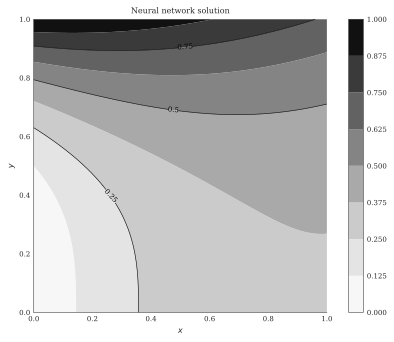

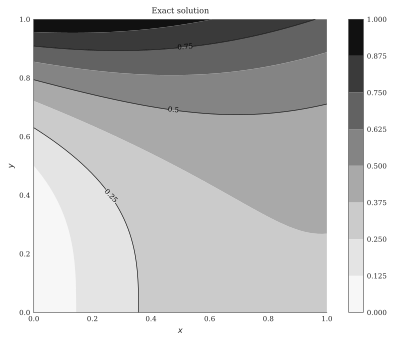

In [5]:
ex5_true_sol = lambda x: torch.exp(-x[:, 0]) * (x[:, 0] + x[:, 1] ** 3)
plot_contour(ex5, ex5_true_sol);

In [6]:
# Problem 6 of Lagaris
a = 3.0
def rhs(x):
    tmp1 = torch.exp(-(a * x[:, 0] + x[:, 1]) / 5.0)
    tmp2 = (-4.0 / 5.0 * a ** 3 * x[:, 0] - 2.0 / 5.0 + 2.0 * a ** 2) * torch.cos(a ** 2 * x[:, 0] ** 2 + x[:, 1])
    tmp2 += (1.0 / 25.0 - 1.0 - 4.0 * a ** 4 * x[:, 0] ** 2 + a ** 2 / 25.0) * torch.sin(a ** 2 * x[:, 0] ** 2 + x[:, 1])
    return tmp1 * tmp2
ex6_true_sol = lambda x: torch.exp(-(a * x[:, 0] + x[:, 1]) / 5.0) * torch.sin(a ** 2 * x[:, 0] ** 2 + x[:, 1])
f0 = lambda x2: ex6_true_sol(torch.stack((torch.zeros_like(x2), x2), dim=1))
f1 = lambda x2: ex6_true_sol(torch.stack((torch.ones_like(x2), x2), dim=1))
g0 = lambda x1: ex6_true_sol(torch.stack((x1, torch.zeros_like(x1)), dim=1))
g1 = lambda x1: ex6_true_sol(torch.stack((x1, torch.ones_like(x1)), dim=1))
net = nn.Sequential(nn.Linear(2, 10), nn.Sigmoid(), nn.Linear(10, 1, bias=False))
ex6 = PDEProblemDC(rhs, f0, f1, g0, g1, net)
x = np.linspace(0, 1, 10)
X, Y = np.meshgrid(x, x)
X_flat = torch.Tensor(np.hstack([X.flatten()[:, None], Y.flatten()[:, None]]))
# Does not always work because of local minima.
# Try multiple times.
# ex6.solve_lbfgs(X_flat, max_iter=10)
ex6.solve_sgd(torch.from_numpy(np.array([[0, 0], [1, 1]], dtype=np.float32)),
              max_iter=10000, batch_size=100, lr=0.01)

it = 99, loss = 2.2737367544323206e-13
it = 199, loss = 2.2737367544323206e-13
it = 299, loss = 2.2737367544323206e-13
it = 399, loss = 2.2737367544323206e-13
it = 499, loss = 2.2737367544323206e-13
it = 599, loss = 2.2737367544323206e-13
it = 699, loss = 2.2737367544323206e-13
it = 799, loss = 2.2737367544323206e-13
it = 899, loss = 2.2737367544323206e-13
it = 999, loss = 2.2737367544323206e-13
it = 1099, loss = 2.2737367544323206e-13
it = 1199, loss = 2.2737367544323206e-13
it = 1299, loss = 2.2737367544323206e-13
it = 1399, loss = 2.2737367544323206e-13
it = 1499, loss = 2.2737367544323206e-13
it = 1599, loss = 2.2737367544323206e-13
it = 1699, loss = 2.2737367544323206e-13
it = 1799, loss = 2.2737367544323206e-13
it = 1899, loss = 2.2737367544323206e-13
it = 1999, loss = 2.2737367544323206e-13
it = 2099, loss = 2.2737367544323206e-13
it = 2199, loss = 2.2737367544323206e-13
it = 2299, loss = 2.2737367544323206e-13
it = 2399, loss = 2.2737367544323206e-13
it = 2499, loss = 2.2737367

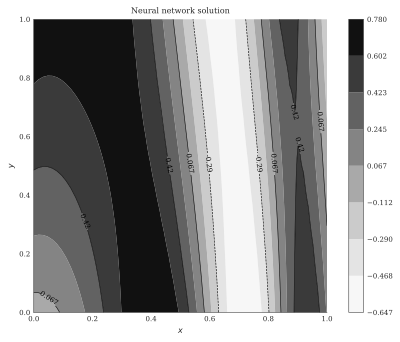

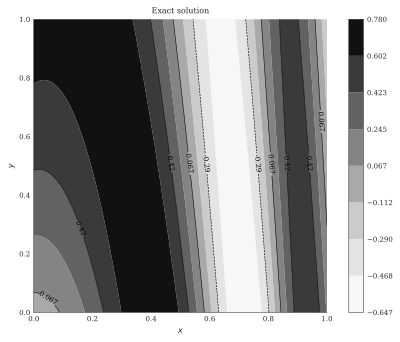

In [7]:
plot_contour(ex6, ex6_true_sol)

### Questions

Feel free to skip this, as it can be challenging if you are not an expert in Python. 

+ Add a method to the class `PDEProblemDC` that uses stochastic gradient descent to solve the same problems. Once you are done, rerun the problems above with your code.
+ According to the [Dirchlet principle](https://en.wikipedia.org/wiki/Dirichlet%27s_principle#:~:text=In%20mathematics%2C%20and%20particularly%20in,a%20solution%20to%20Poisson's%20equation.), the solution of the PDE:

$$
\frac{\partial^2}{\partial x^2}\Psi(x,y) + \frac{\partial^2}{\partial y^2}\Psi(x,y) = f(x,y),
$$

minimizes the energy functional:

$$
J[\Psi] = \int_{[0,1]^2} \left[\frac{1}{2}\parallel \nabla \Psi\parallel^2 + \Psi f\right]dxdy,
$$

subject to the boundary conditions.
This means that you can solve the problem by minimizing the loss function:

$$
J(\theta) = \int_{[0,1]^2} \left[\frac{1}{2}\parallel \nabla \hat{\Psi}(x,y;\theta)\parallel^2 + \hat{\Psi}(x,y;\theta) f(x,y)\right]dxdy.
$$

Add this functionality to the class `PDEProblemDC`.